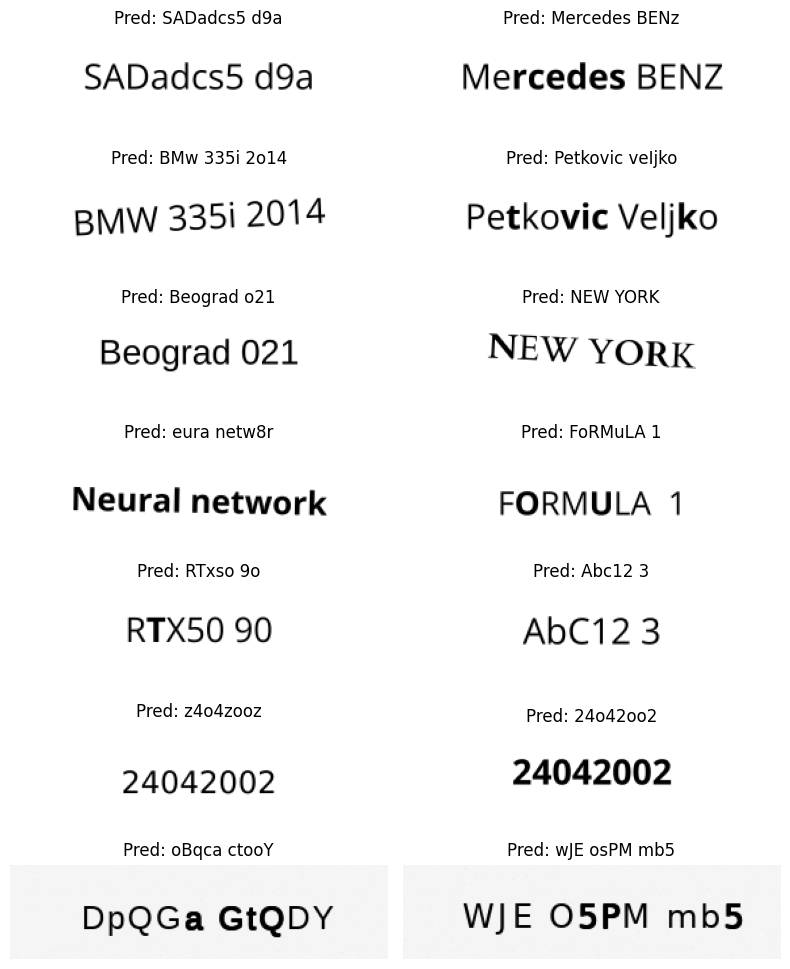

In [13]:
from models.model_hff_cnn_transformer import HFFCNNTransformerOCR
from models.model_cnn_transformer import CNNTransformerOCR, idx2char
from config import *
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

PATH = "saved_models/cnn_transformer_ctc_best.pt" # path to saved model
PATH_HFF = "saved_models/cnn_hff_cnn_transformer_ctc_best.pt" # path to saved model

@torch.no_grad()
def greedy_decode(logits):
    """
    Single-sample CTC greedy decode. Takes argmax at each timestep,
    collapses consecutive duplicates, and removes blank tokens - index 0
    """
    preds = logits.argmax(dim=2).squeeze(1).tolist()  # [T]
    out = []
    prev = None
    for p in preds:
        if p != prev and p != 0:
            out.append(idx2char[p])
        prev = p
    return "".join(out)

num_classes = 1 + len(ALPHABET)

ckpt = torch.load(PATH, map_location=DEVICE)
model = CNNTransformerOCR(num_classes)
#ckpt = torch.load(PATH_HFF, map_location=DEVICE)
#model = HFFCNNTransformerOCR(num_classes)

model.load_state_dict(ckpt["model"])
model.to(DEVICE)
model.eval()

# Converts input images to the format expected by the model:
# grayscale, resized to (IMG_H x IMG_W), normalized to [-1, 1]
tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

image_paths = [f"dataset/testing_images/{i}.png" for i in range(1, 15)]

images = []
predictions = []

for p in image_paths:
    img = Image.open(p).convert("L")
    x = tf(img).unsqueeze(0).to(DEVICE)  # [1,1,32,168]

    with torch.no_grad():
        logits = model(x)
        pred_text = greedy_decode(logits)

    images.append(img)
    predictions.append(pred_text)

# Display all test images in a 7x2 grid with predicted text as titles
fig, axes = plt.subplots(7, 2, figsize=(8, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()